# Ablation 2: Focal Loss with Albumentations

> **Purpose**: Test aggressive data augmentation with Albumentations library

## Configuration
| Setting | Value |
|---------|-------|
| **Loss Function** | Focal Loss (γ=2.0) |
| **Augmentation** | Albumentations (ImageCompression, GaussNoise, GaussianBlur) |
| **Early Stopping** | Patience = 5 |
| **Class Weights** | None |

## Hypothesis
Albumentations with compression artifacts simulation should improve generalization.

In [ ]:
from pathlib import Path
import os
import random
import shutil

import numpy as np
import torch

DATA_ROOT = Path("FFprocessed")
OUT_ROOT = Path("data_yolo_faces")

OUT_ROOT.mkdir(exist_ok=True)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("DATA_ROOT:", DATA_ROOT.resolve())
print("OUT_ROOT:", OUT_ROOT.resolve())

DATA_ROOT: C:\Users\Jesslyn\Documents\Semester 5\DL_FINPRO\deep-learning-final-project\FFprocessed
OUT_ROOT: C:\Users\Jesslyn\Documents\Semester 5\DL_FINPRO\deep-learning-final-project\data_yolo_faces


In [ ]:
from collections import defaultdict

REAL_METHOD = "original"
FAKE_METHODS = [
    "Deepfakes",
    "FaceSwap",
    "Face2Face",
    "NeuralTextures",
    "FaceShifter",
    "DeepFakeDetection",
]

video_entries = []

for method in [REAL_METHOD] + FAKE_METHODS:
    method_dir = DATA_ROOT / method
    if not method_dir.exists():
        print(f"Warning: method folder not found: {method_dir}")
        continue

    for video_dir in method_dir.iterdir():
        if not video_dir.is_dir():
            continue
        imgs = [p for p in video_dir.iterdir() if p.is_file()]
        if not imgs:
            continue
        label = "REAL" if method == REAL_METHOD else "FAKE"
        video_entries.append({
            "method": method,
            "video_id": video_dir.name,
            "label": label,
            "path": str(video_dir),
            "num_frames": len(imgs),
        })

print("Total videos found:", len(video_entries))
labels = [e["label"] for e in video_entries]
print("Label counts:", {"REAL": labels.count("REAL"), "FAKE": labels.count("FAKE")})

import numpy as np
from sklearn.model_selection import train_test_split

indices = np.arange(len(video_entries))
labels_np = np.array(labels)

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=labels_np,
    random_state=RANDOM_STATE,
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=labels_np[temp_idx],
    random_state=RANDOM_STATE,
)

def subset(entries, idx):
    return [entries[i] for i in idx]

train_videos = subset(video_entries, train_idx)
val_videos = subset(video_entries, val_idx)
test_videos = subset(video_entries, test_idx)

def count_labels(entries):
    c = defaultdict(int)
    for e in entries:
        c[e["label"]] += 1
    return dict(c)

print("Train videos:", len(train_videos), count_labels(train_videos))
print("Val videos:", len(val_videos), count_labels(val_videos))
print("Test videos:", len(test_videos), count_labels(test_videos))

In [ ]:
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

def copy_image(src, dst):
    if not dst.exists():
        try:
            shutil.copy2(src, dst)
            return True
        except Exception as ex:
            print(f"Copy failed for {src} → {dst}: {ex}")
    return False

def prepare_split(split_name, entries, max_workers=8):
    split_root = OUT_ROOT / split_name
    (split_root / "REAL").mkdir(parents=True, exist_ok=True)
    (split_root / "FAKE").mkdir(parents=True, exist_ok=True)

    num_copied = 0
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = []
        for e in tqdm(entries, desc=f"{split_name} videos", unit="video"):
            src_video_dir = Path(e["path"])
            label = e["label"]
            dst_dir = split_root / label

            img_paths = [img_path for img_path in src_video_dir.iterdir() if img_path.is_file()]
            for img_path in tqdm(img_paths, desc=f"{e['video_id']} images", leave=False, unit="img"):
                dst_path = dst_dir / f"{e['method']}_{e['video_id']}_{img_path.name}"
                futures.append(executor.submit(copy_image, img_path, dst_path))

        for f in tqdm(as_completed(futures), total=len(futures), desc="Copying images", unit="img"):
            if f.result():
                num_copied += 1

    print(f"Prepared split {split_name}: {num_copied} images")

prepare_split("train", train_videos)
prepare_split("val", val_videos)
prepare_split("test", test_videos)

In [ ]:
from collections import defaultdict

def get_split_entries(split_name):
    split_root = OUT_ROOT / split_name
    entries = []
    for label in ["REAL", "FAKE"]:
        label_dir = split_root / label
        if not label_dir.exists():
            print(f"Warning: label folder not found: {label_dir}")
            continue
        for item in label_dir.iterdir():
            if item.is_file():
                entries.append({
                    "label": label,
                    "path": str(item.resolve()),
                    "filename": item.name,
                })
    return entries

train_videos = get_split_entries("train")
val_videos = get_split_entries("val")
test_videos = get_split_entries("test")

def count_labels(entries):
    c = defaultdict(int)
    for e in entries:
        c[e["label"]] += 1
    return dict(c)

print("Train images:", len(train_videos), count_labels(train_videos))
print("Val images:", len(val_videos), count_labels(val_videos))
print("Test images:", len(test_videos), count_labels(test_videos))

Train images: 97156 {'REAL': 13843, 'FAKE': 83313}
Val images: 20759 {'REAL': 2970, 'FAKE': 17789}
Test images: 20784 {'REAL': 2960, 'FAKE': 17824}


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

faces_dir = OUT_ROOT

train_transform_alb = A.Compose([
    A.Resize(256, 256),
    A.RandomCrop(224, 224),
    A.HorizontalFlip(p=0.5),
    A.ImageCompression(quality_lower=60, quality_upper=100, p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

eval_transform_alb = A.Compose([
    A.Resize(256, 256),
    A.CenterCrop(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

class AlbumentationsDataset(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super(AlbumentationsDataset, self).__init__(root, transform=None)
        self.alb_transform = transform

    def __getitem__(self, index):
        path, target = self.samples[index]
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.alb_transform:
            augmented = self.alb_transform(image=image)
            image = augmented['image']
            
        return image, target

train_dataset = AlbumentationsDataset(root=str(faces_dir / "train"), transform=train_transform_alb)
val_dataset = AlbumentationsDataset(root=str(faces_dir / "val"), transform=eval_transform_alb)
test_dataset = AlbumentationsDataset(root=str(faces_dir / "test"), transform=eval_transform_alb)

print("Classes:", train_dataset.classes)
print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))
print("Test images:", len(test_dataset))

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cuda


C:\Users\Jesslyn\AppData\Local\Temp\ipykernel_31124\798114803.py:25: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=60, quality_upper=100, p=0.5),
C:\Users\Jesslyn\AppData\Local\Temp\ipykernel_31124\798114803.py:28: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),


Classes: ['FAKE', 'REAL']
Train images: 97156
Val images: 20759
Test images: 20784


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

def create_model(num_classes=2, use_pretrained=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes),
    )
    return model

model = create_model(num_classes=2, use_pretrained=True).to(device)
criterion = FocalLoss(alpha=0.25, gamma=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

print("Model created with Focal Loss.")
print(model.fc)

Model created with Focal Loss.
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=2, bias=True)
)


In [ ]:
import time
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for inputs, labels in tqdm(loader, desc="Training", unit="batch"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for inputs, labels in tqdm(loader, desc="Validation", unit="batch"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

num_epochs = 20
patience = 5
no_improve_count = 0

best_val_acc = 0.0
best_state_dict = None

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    start_time = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    elapsed = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs} | ",
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, ",
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, ",
        f"time={elapsed:.1f}s"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = model.state_dict()
        no_improve_count = 0
        print(f"--> New Best Model! (Acc: {best_val_acc:.4f})")
    else:
        no_improve_count += 1
        print(f"--> No improvement for {no_improve_count}/{patience} epochs.")
    
    if no_improve_count >= patience:
        print("Early Stopping triggered! Stopping training.")
        break

print("Best val acc:", best_val_acc)

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    torch.save(model.state_dict(), "albumentations_model.pth")
    print("Saved best model to albumentations_model.pth")

Validation: 100%|██████████| 325/325 [01:27<00:00,  3.73batch/s]


Epoch 1/20 |  train_loss=0.0219, train_acc=0.8744,  val_loss=0.0176, val_acc=0.8984,  time=628.4s
--> New Best Model! (Acc: 0.8984)


Validation: 100%|██████████| 325/325 [01:23<00:00,  3.91batch/s]


Epoch 2/20 |  train_loss=0.0148, train_acc=0.9142,  val_loss=0.0206, val_acc=0.8719,  time=608.1s
--> No improvement for 1/5 epochs.


Validation: 100%|██████████| 325/325 [01:25<00:00,  3.78batch/s]


...

Epoch 12/20 |  train_loss=0.0067, train_acc=0.9600,  val_loss=0.0227, val_acc=0.9214,  time=607.7s
--> No improvement for 3/5 epochs.


Validation: 100%|██████████| 325/325 [01:25<00:00,  3.79batch/s]


Epoch 13/20 |  train_loss=0.0064, train_acc=0.9613,  val_loss=0.0192, val_acc=0.9315,  time=611.0s
--> No improvement for 4/5 epochs.


Validation: 100%|██████████| 325/325 [01:25<00:00,  3.82batch/s]

Epoch 14/20 |  train_loss=0.0062, train_acc=0.9624,  val_loss=0.0186, val_acc=0.9333,  time=611.4s
--> No improvement for 5/5 epochs.
Early Stopping triggered! Stopping training.
Best val acc: 0.9358832313695264
Saved best model to albumentations_model.pth


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

@torch.no_grad()
def evaluate_simple(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()
        total += inputs.size(0)
    return correct / total if total > 0 else 0.0

test_acc = evaluate_simple(model, test_loader, device)
print("Test accuracy (YOLO faces):", test_acc)

Test accuracy (YOLO faces): 0.9281177829099307


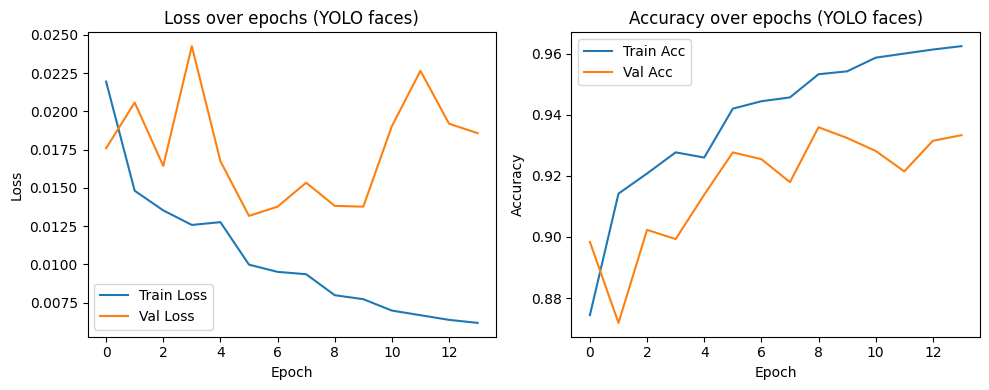

Confusion Matrix (rows=true, cols=pred):
[[17215   609]
 [  885  2075]]

Classification Report:
              precision    recall  f1-score   support

        FAKE     0.9511    0.9658    0.9584     17824
        REAL     0.7731    0.7010    0.7353      2960

    accuracy                         0.9281     20784
   macro avg     0.8621    0.8334    0.8469     20784
weighted avg     0.9258    0.9281    0.9266     20784



In [10]:
import matplotlib.pyplot as plt


# Plot training and validation loss/accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over epochs (YOLO faces)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over epochs (YOLO faces)")
plt.legend()

plt.tight_layout()
plt.show()

@torch.no_grad()
def get_predictions_and_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return all_preds, all_labels

y_pred, y_true = get_predictions_and_labels(model, test_loader, device)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix (rows=true, cols=pred):")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=train_dataset.classes, digits=4))